# Task 3: Temporal Regression Models & Short-Term Forecasting
This notebook explores the temporal characteristics of global earthquake data. We focus heavily on temporal regression models and short term forecasting as required by Task 3.
Key adjustments and visualizations addressed:
1. **Mathematical Transformations**: Using Log/Box-Cox transforms to simplify TS structure.
2. **Exploratory Data Analysis:** STL decomposition, Loess smoothing.
3. **Advanced Visualizations:** 2-sided plots, Scatterplot Matrices, Seasonal/Lag/ACF plots.
4. **Temporal Regression Models (Predictors):** Using Trend, Seasonal Dummies, Intervention Dummies, Outliers, Distributed Lags, and Fourier series.
5. **Regression Diagnostics:** Innovation residuals, outlier influence, ACF/Histogram of residuals, Residuals vs Predictors.
6. **Short-Term Forecasting (ETS & ARIMA):** Ex-post validation (holdout testing 2020-2024 timeframe) and Ex-Ante forecasting (true future predictions out of sample). Includes 80% and 95% predictive intervals.

In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas.plotting import lag_plot, scatter_matrix
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')

# Premium Styling ensuring clear, readable graphs with single plots per cell
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
colors = sns.color_palette("viridis", 12)

## 1. Data Preparation & Holdout Split (Ex-Post Structure)
We take the last few years (2020-2024) of the dataset as our holdout test set to validate our short-term predictability.

In [73]:
df = pd.read_csv('dataset_preprocessed.csv')

df['time'] = pd.to_datetime(df['time'], format='mixed', utc=True)
df = df.sort_values('time')

# Aggregate to Monthly Frequency
ts_data = df.resample('MS', on='time').agg({
    'mag': ['count', 'mean', 'max'],
    'energy_J': 'sum',
    'depth': 'mean'
})

ts_data.columns = ['count', 'mag_mean', 'mag_max', 'energy_sum', 'depth_mean']

# Handling any missing months robustly
ts_data = ts_data.ffill()

print(f"Data spanning from {ts_data.index.min()} to {ts_data.index.max()}")
ts_data.head()

Data spanning from 2000-01-01 00:00:00+00:00 to 2025-06-01 00:00:00+00:00


,count,mag_mean,mag_max,energy_sum,depth_mean
time,,,,,
2000-01-01 00:00:00+00:00,275,4.906873,6.2,1.566875e+15,47.592618
2000-02-01 00:00:00+00:00,265,4.886415,6.2,1.128619e+15,47.215015
2000-03-01 00:00:00+00:00,290,4.858276,6.1,9.223218e+14,44.239666
2000-04-01 00:00:00+00:00,288,4.823958,6.2,9.262895e+14,50.601924
2000-05-01 00:00:00+00:00,330,4.811909,6.0,9.662983e+14,46.556342


### Visualization 1: Train/Test Split Showcase
Defining our Holdout Validation sets.

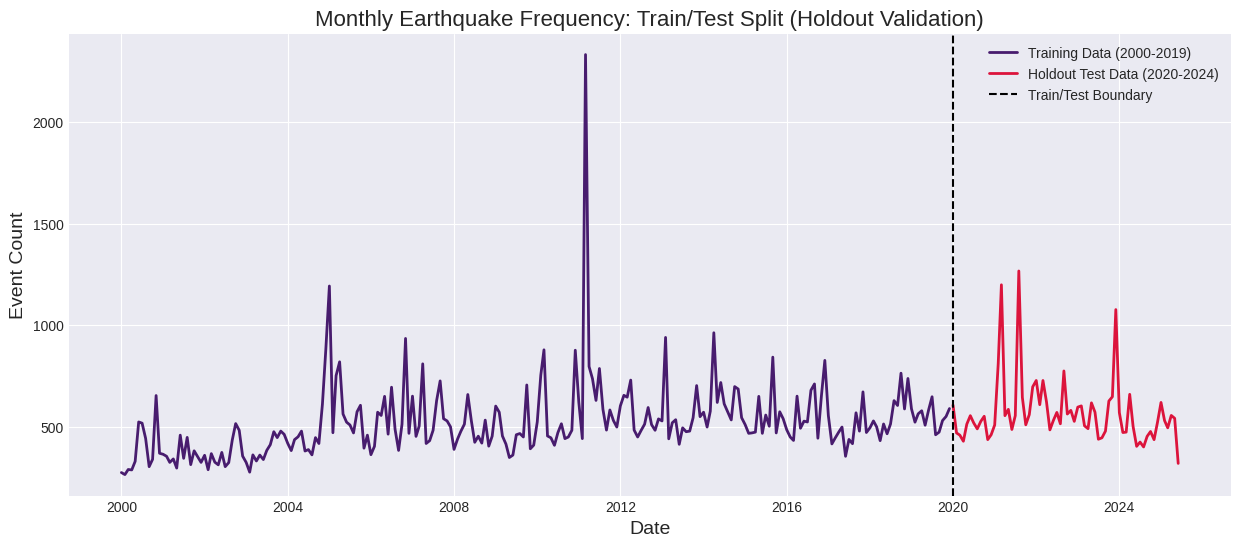

In [74]:
# Holdout Split (2020 onwards)
train = ts_data[:'2019-12-31']
test = ts_data['2020-01-01':]

plt.figure(figsize=(15, 6))
plt.plot(train.index, train['count'], label='Training Data (2000-2019)', color=colors[0], lw=2)
plt.plot(test.index, test['count'], label='Holdout Test Data (2020-2024)', color='crimson', lw=2)
plt.axvline(x=test.index[0], color='black', linestyle='--', label='Train/Test Boundary')
plt.title('Monthly Earthquake Frequency: Train/Test Split (Holdout Validation)')
plt.xlabel('Date')
plt.ylabel('Event Count')
plt.legend()
plt.show()

## 2. Advanced Exploratory Time Series Visualizations
### Visualization 2: 2-Sided Mirror Plot (Frequency vs Energy)
Comparing the count of events against the total energy released. Notice the distinct spikes in energy.

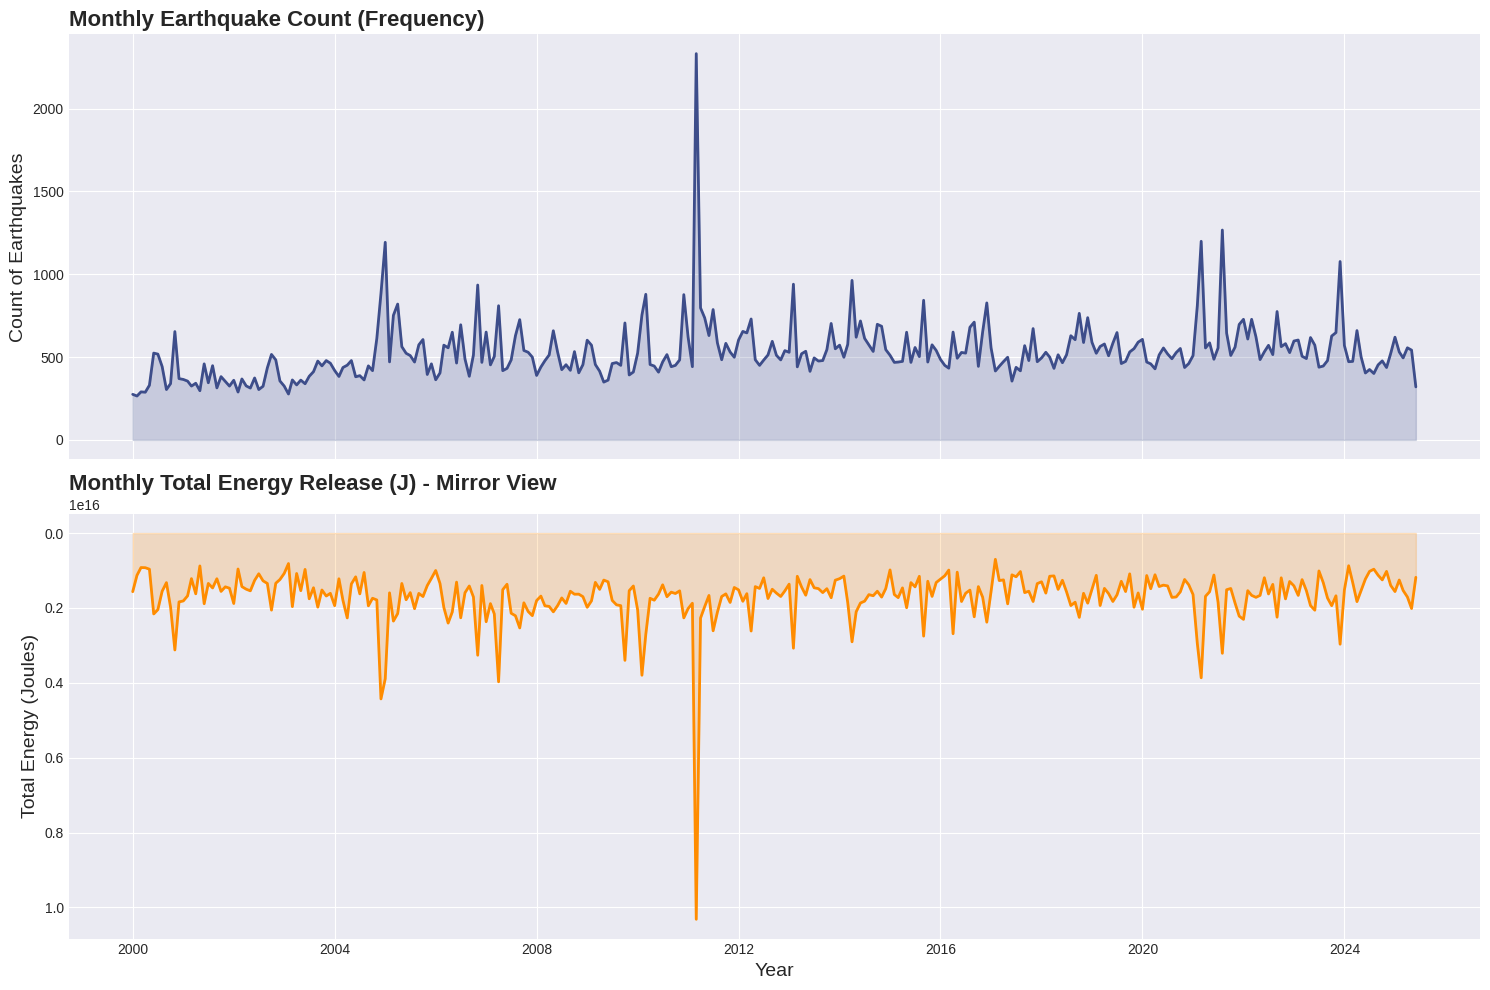

In [75]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(15, 10))

ax[0].plot(ts_data.index, ts_data['count'], color=colors[2], lw=2)
ax[0].set_title('Monthly Earthquake Count (Frequency)', loc='left', fontweight='bold')
ax[0].fill_between(ts_data.index, ts_data['count'], color=colors[2], alpha=0.2)
ax[0].set_ylabel('Count of Earthquakes')

ax[1].plot(ts_data.index, ts_data['energy_sum'], color='darkorange', lw=2)
ax[1].set_title('Monthly Total Energy Release (J) - Mirror View', loc='left', fontweight='bold')
ax[1].fill_between(ts_data.index, ts_data['energy_sum'], color='darkorange', alpha=0.2)
ax[1].invert_yaxis()
ax[1].set_ylabel('Total Energy (Joules)')
ax[1].set_xlabel('Year')

plt.tight_layout()
plt.show()

### Visualization 3: Scatterplot Matrix for Multivariate TS
Checking linear/nonlinear relationships and multicollinearity among variables.

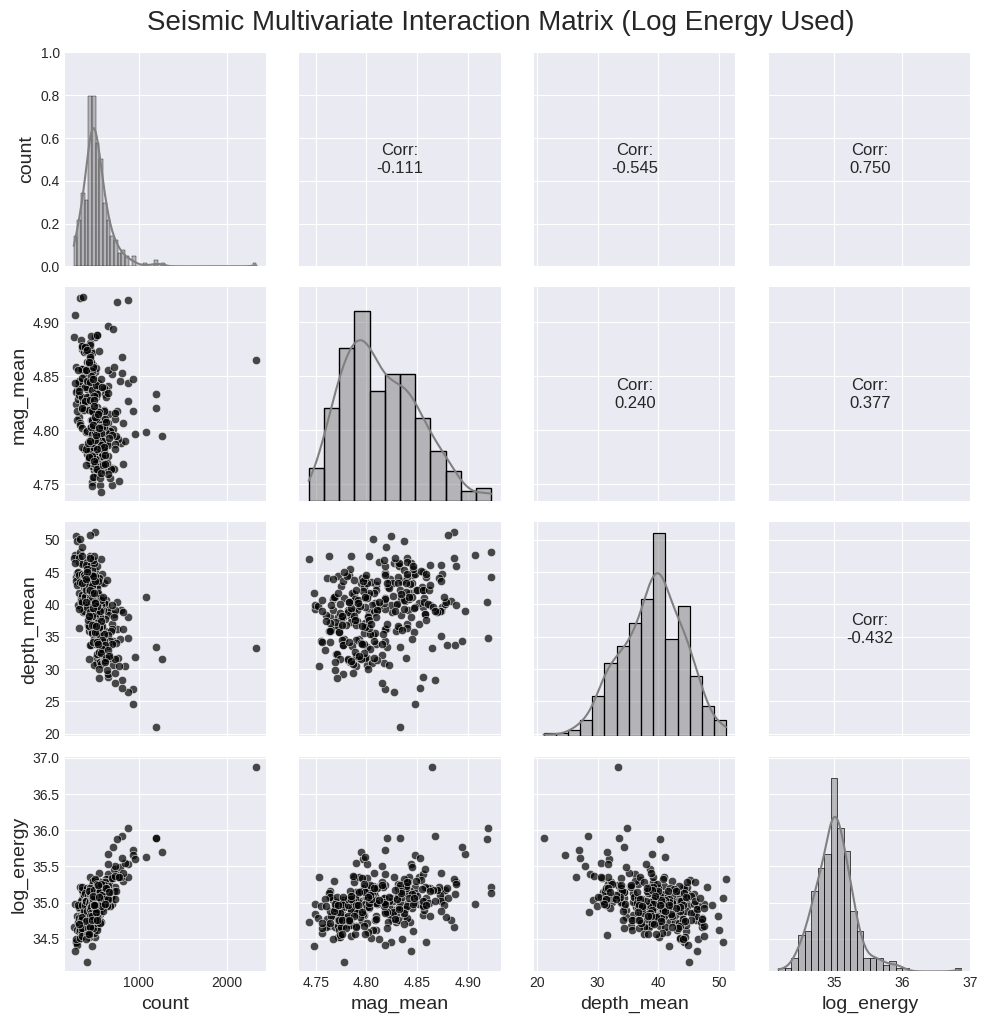

In [76]:
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0,1]
    ax = plt.gca()
    ax.annotate(f"Corr:\n{r:.3f}",
                xy=(.5,.5),
                xycoords=ax.transAxes,
                ha='center',
                va='center',
                fontsize=12)
ts_data['log_energy'] = np.log1p(ts_data['energy_sum'])
pair = sns.PairGrid(
    ts_data[['count','mag_mean','depth_mean','log_energy']].dropna()
)

pair.map_lower(sns.scatterplot, color='black', alpha=0.7)
pair.map_diag(sns.histplot, kde=True, color='gray')
pair.map_upper(corrfunc)

pair.figure.suptitle(
    "Seismic Multivariate Interaction Matrix (Log Energy Used)",
    fontsize=20, y=1.02
)
plt.show()

### Visualization 4: Seasonal Plot
Checking for calendar seasonality patterns (Adjusting the historical data for calendar effects).

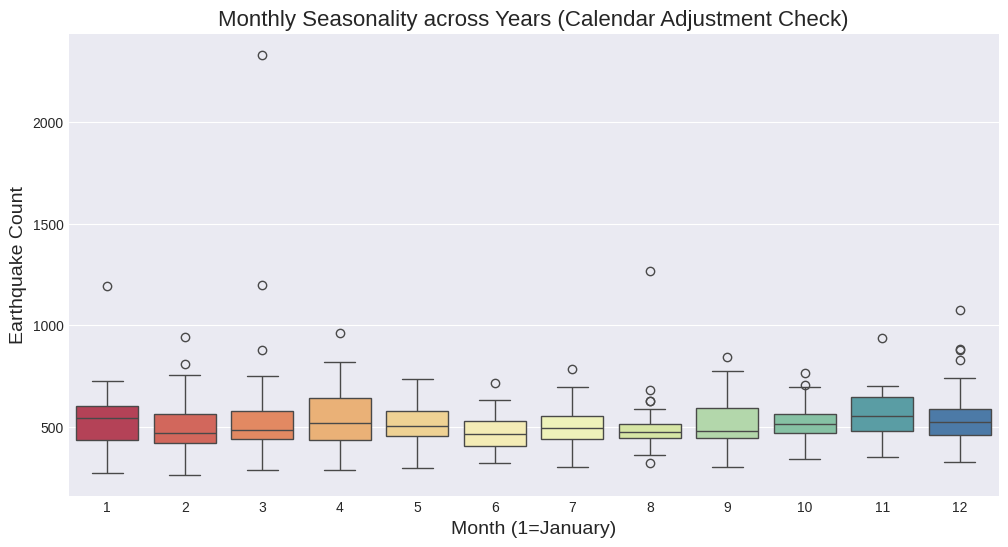

In [77]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=ts_data.index.month, y=ts_data['count'], palette='Spectral')
plt.title('Monthly Seasonality across Years (Calendar Adjustment Check)')
plt.xlabel('Month (1=January)')
plt.ylabel('Earthquake Count')
plt.show()

### Visualization 5: Lag Plot
Checking the auto-dependence of consecutive values (Lag=1).

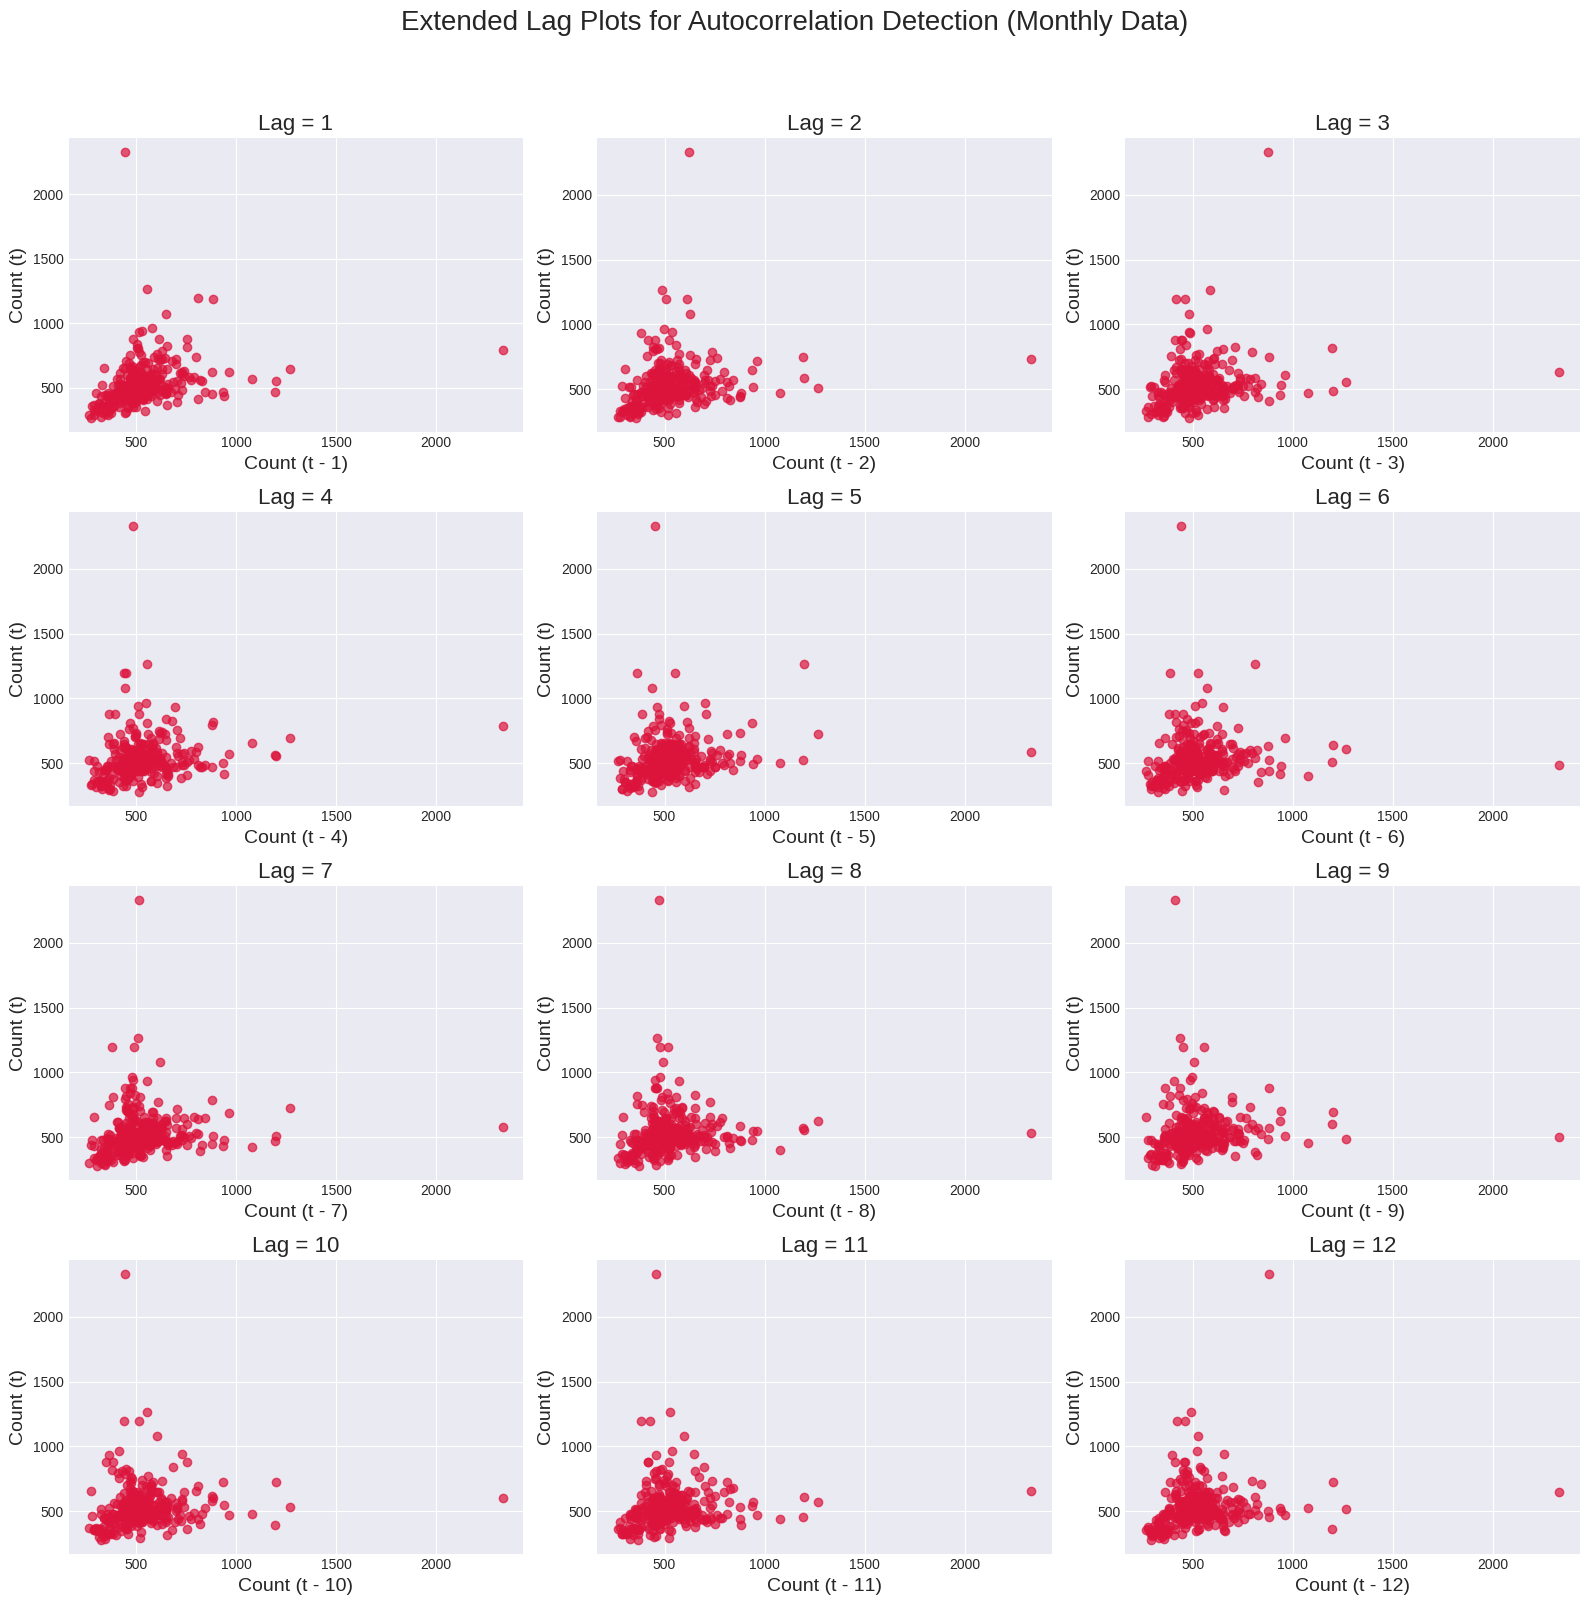

In [78]:
lags = list(range(1, 13)) # Checking 12 lags (a full year)

# Set up a grid for 12 plots (e.g., 4 rows x 3 columns)
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, lag in enumerate(lags):
    lag_plot(ts_data['count'], lag=lag, ax=axes[i],
             c='crimson', alpha=0.7) 
    axes[i].set_title(f'Lag = {lag}')
    axes[i].set_xlabel(f'Count (t - {lag})')
    axes[i].set_ylabel(f'Count (t)')

plt.suptitle('Extended Lag Plots for Autocorrelation Detection (Monthly Data)', fontsize=20, y=1.01)
plt.tight_layout(rect=[0, 0.01, 1, 0.98]) # Adjust layout for the suptitle
plt.show()

### Visualization 6: Autocorrelation Function (ACF)
Necessary for analyzing serial dependence with confidence bounds.

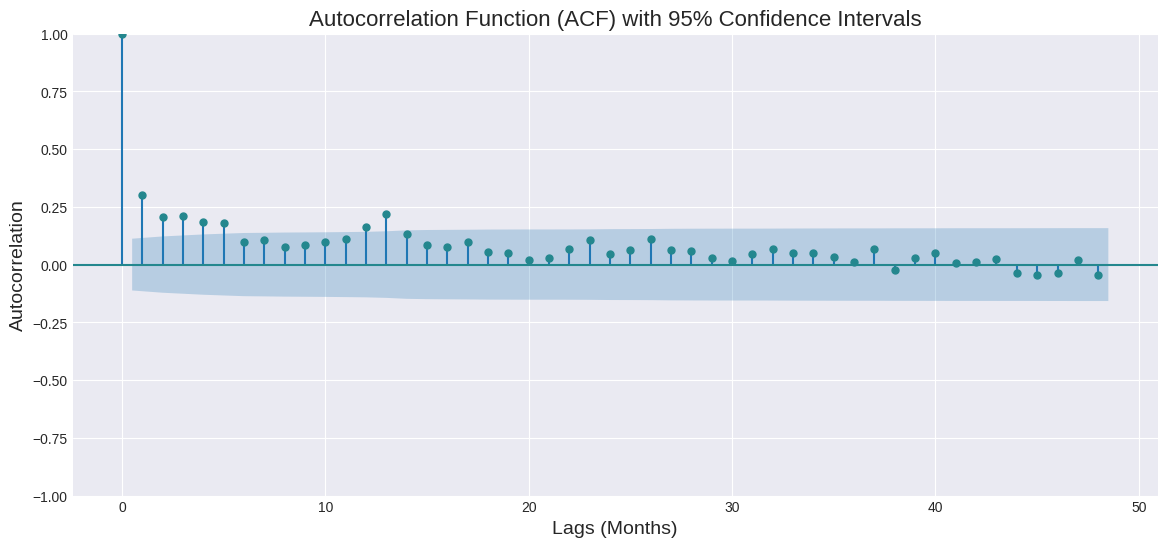

In [79]:
plt.figure(figsize=(14, 6))
ax = plt.gca()
plot_acf(ts_data['count'], ax=ax, lags=48, color=colors[5], alpha=0.05) # 95% Confidence Intervals
plt.title('Autocorrelation Function (ACF) with 95% Confidence Intervals')
plt.xlabel('Lags (Months)')
plt.ylabel('Autocorrelation')
plt.show()

### Visualization 7: Partial Autocorrelation Function (PACF)
Helps determine the Auto-Regressive (AR) terms for ARIMA.

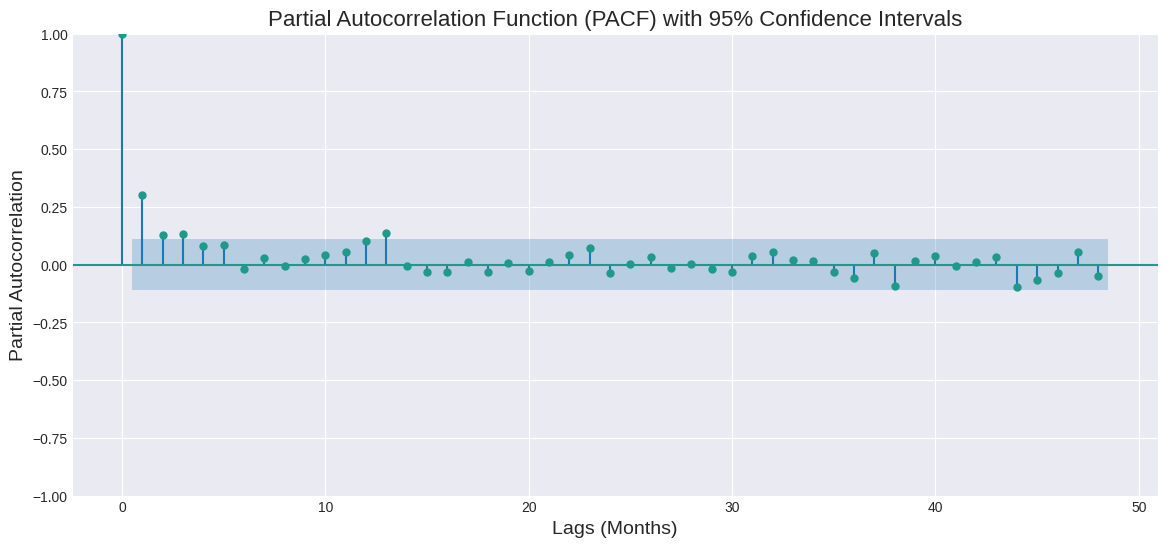

In [80]:
plt.figure(figsize=(14, 6))
ax = plt.gca()
plot_pacf(ts_data['count'], ax=ax, lags=48, color=colors[6], alpha=0.05)
plt.title('Partial Autocorrelation Function (PACF) with 95% Confidence Intervals')
plt.xlabel('Lags (Months)')
plt.ylabel('Partial Autocorrelation')
plt.show()

## 3. Data Adjustments & Transformations
Adjusting the historical data can often lead to simpler time series modeling by stripping known variation sources.

### Visualization 8: Mathematical Transformation (Log / Additive Stability)
Transforming the highly skewed `energy_sum` variable using Log to make the additive variance more consistent before TS decomposition.

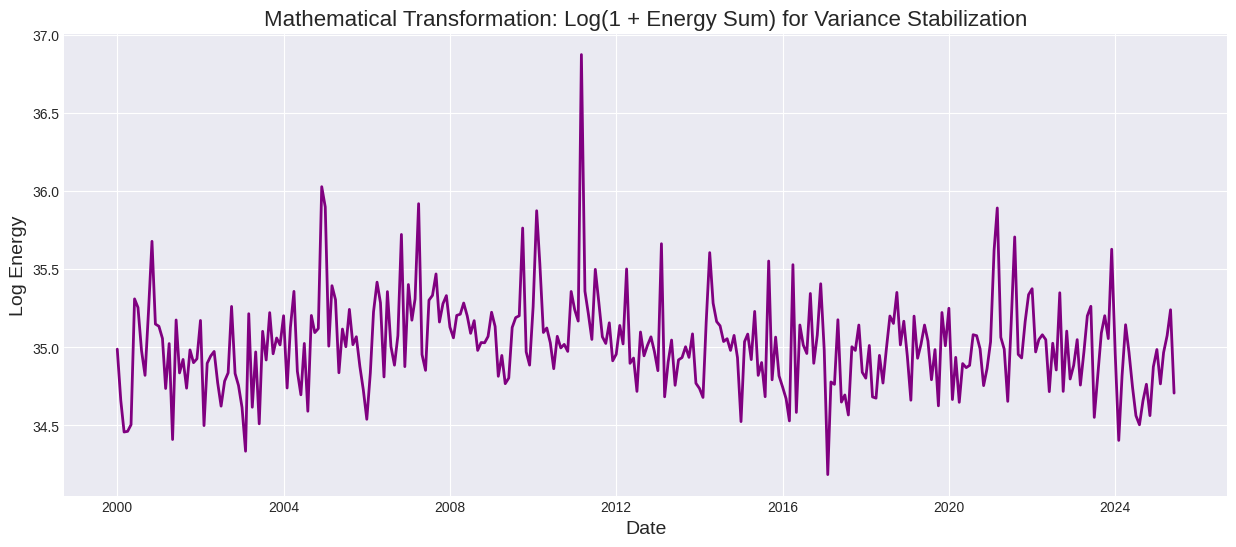

In [81]:
ts_data['log_energy'] = np.log1p(ts_data['energy_sum'])

plt.figure(figsize=(15, 6))
plt.plot(ts_data.index, ts_data['log_energy'], color='purple', lw=2)
plt.title('Mathematical Transformation: Log(1 + Energy Sum) for Variance Stabilization')
plt.xlabel('Date')
plt.ylabel('Log Energy')
plt.show()

### Visualization 9: STL Decomposition (Seasonal / Trend / Remainder)
Decomposing the series to assess Additive Components.

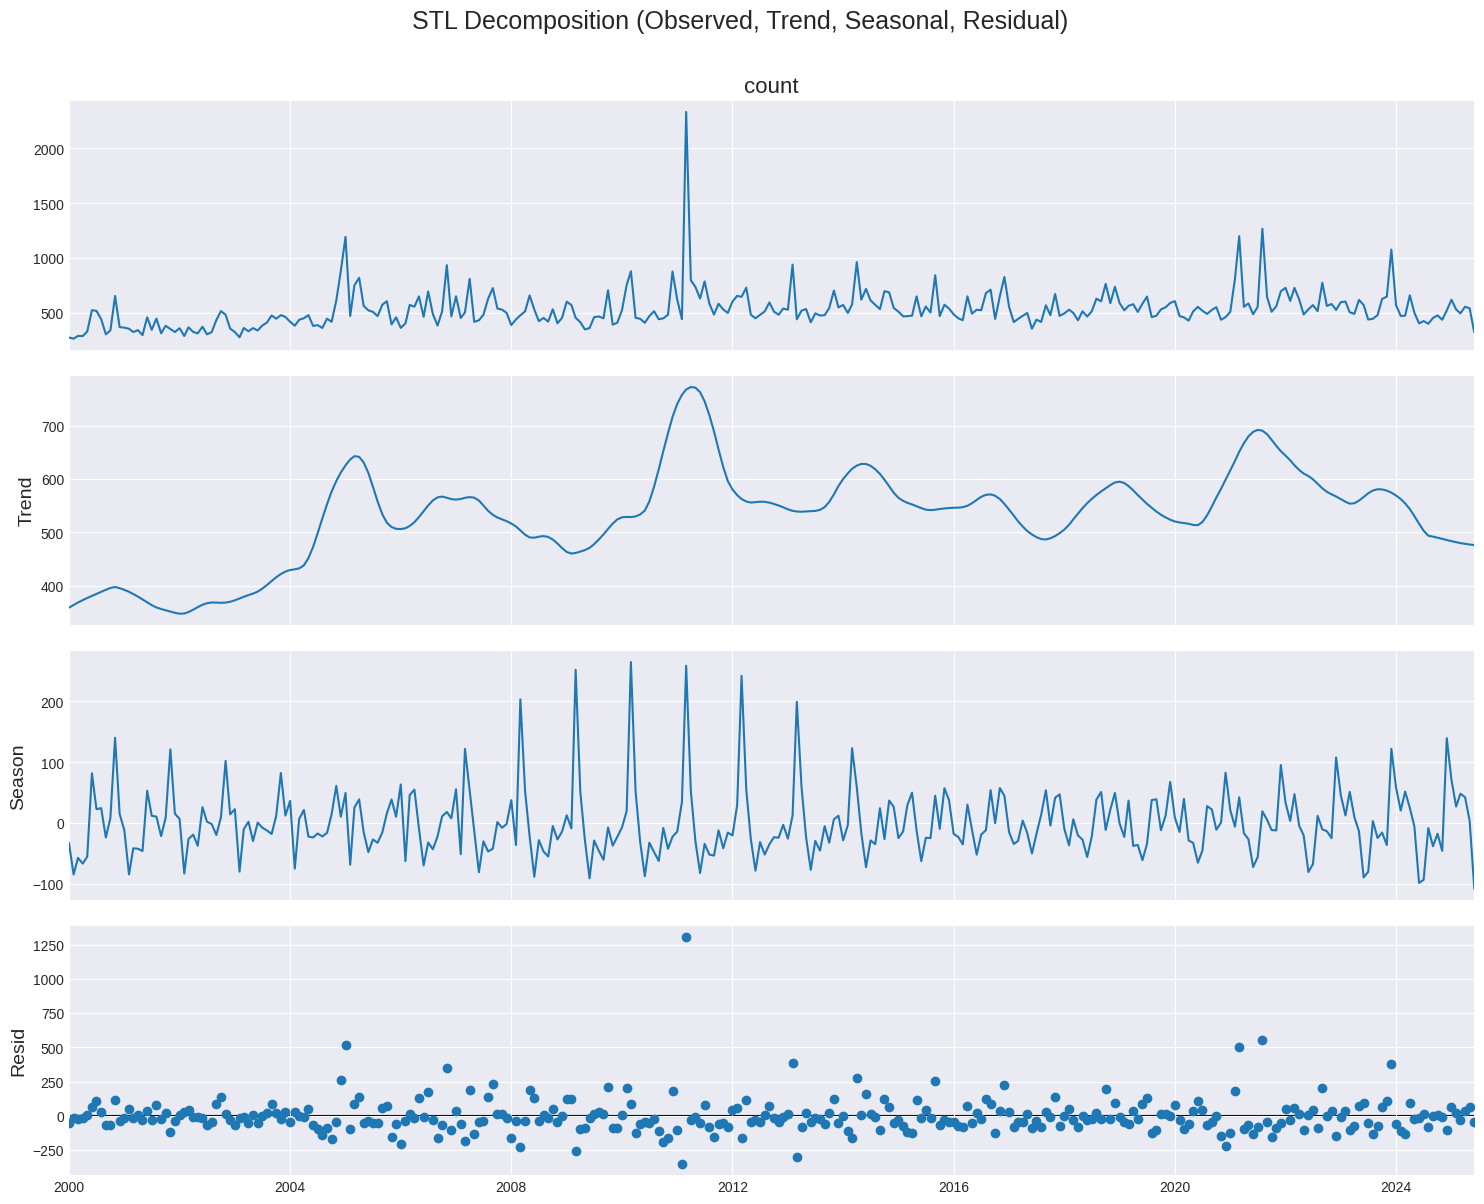

In [82]:
stl = STL(ts_data['count'], seasonal=13)
res = stl.fit()
fig = res.plot()
fig.set_size_inches(15, 12)
fig.suptitle('STL Decomposition (Observed, Trend, Seasonal, Residual)', fontsize=18, y=1.02)
plt.show()

### Visualization 10: Loess Regression (Moving Averages Smoothing)
Isolating the underlying trend and removing noise/seasonal variation using non-linear Loess smoothing.

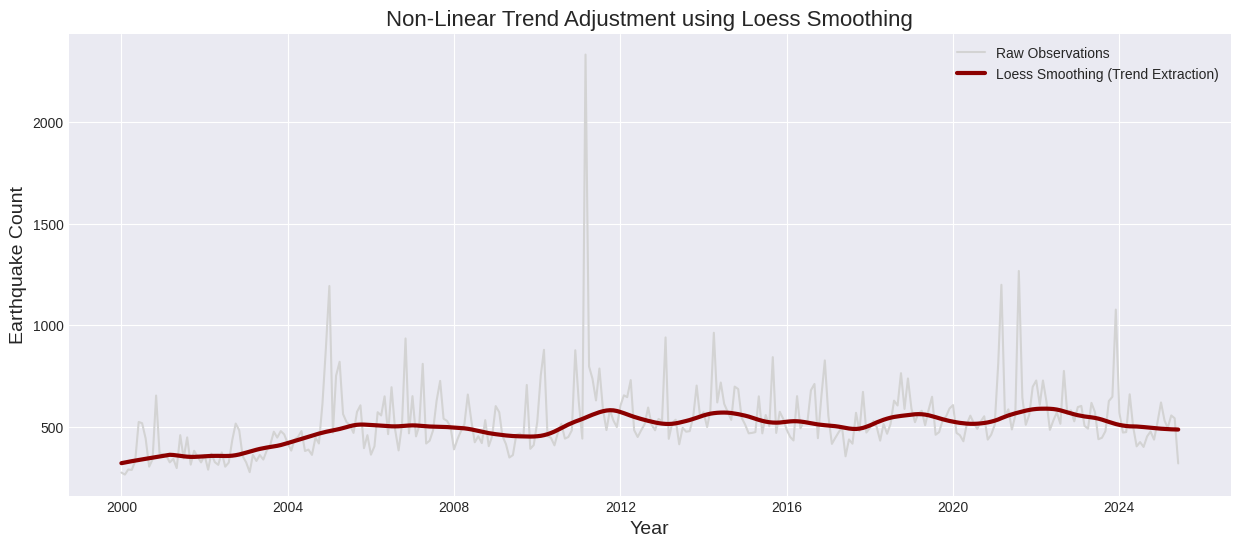

In [83]:
smoothed = lowess(ts_data['count'], np.arange(len(ts_data)), frac=0.1)

plt.figure(figsize=(15, 6))
plt.plot(ts_data.index, ts_data['count'], label='Raw Observations', color='lightgray')
plt.plot(ts_data.index, smoothed[:, 1], label='Loess Smoothing (Trend Extraction)', color='darkred', lw=3)
plt.title('Non-Linear Trend Adjustment using Loess Smoothing')
plt.xlabel('Year')
plt.ylabel('Earthquake Count')
plt.legend()
plt.show()

## 4. Temporal Regression Modeling
We sequentially build Predictive TS Regression models using various predictors (Trend, Seasonality, Interventions, Distributed Lags). 

### Visualization 11: Regression with Trend & Seasonal Dummy Variables

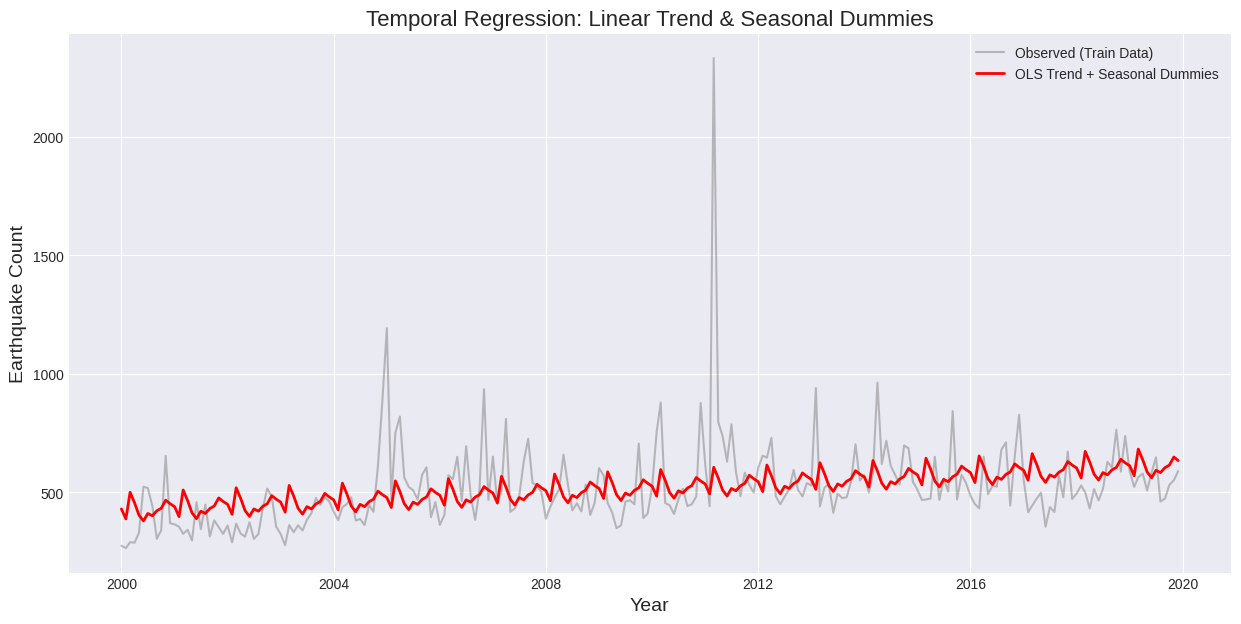

In [84]:
df_reg = train.copy()

df_reg['time_idx'] = np.arange(len(df_reg))
df_reg['month'] = df_reg.index.month

# Seasonal Dummy Predictors
df_reg = pd.get_dummies(df_reg, columns=['month'], drop_first=True)

X = df_reg.drop(['count', 'mag_mean', 'mag_max', 'energy_sum', 'depth_mean'], axis=1)

# Convert all columns to numeric explicitly
X = X.astype(float)
X = sm.add_constant(X)

y = df_reg['count'].astype(float)

lin_model = sm.OLS(y, X).fit()
df_reg['lin_pred'] = lin_model.predict(X)

plt.figure(figsize=(15, 7))
plt.plot(df_reg.index, y, label='Observed (Train Data)', alpha=0.5, color='gray')
plt.plot(df_reg.index, df_reg['lin_pred'], label='OLS Trend + Seasonal Dummies', color='red', lw=2)
plt.title('Temporal Regression: Linear Trend & Seasonal Dummies')
plt.xlabel('Year')
plt.ylabel('Earthquake Count')
plt.legend()
plt.show()

### Visualization 12: Distributed Lags (Cumulative Effect Predictors)
For earthquakes, high magnitudes spanning across a period often trigger cascading aftershocks. We introduce a distributed lag matrix (past 3 months of Max Magnitude) as predictors to anticipate current Counts.

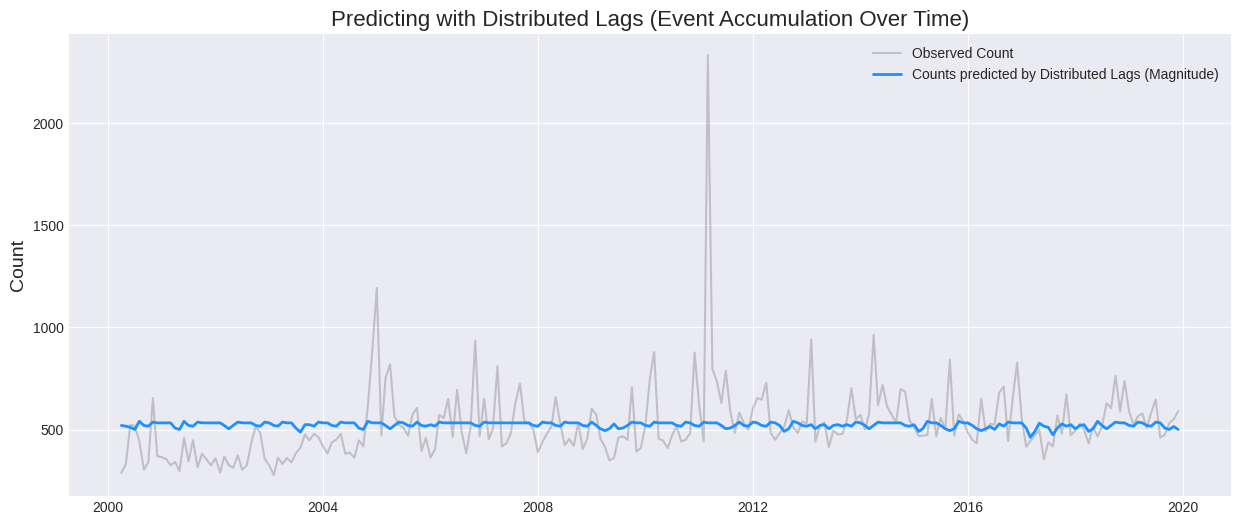

In [85]:
lag_df = train[['count', 'mag_max']].copy()
lag_df['mag_max_lag1'] = lag_df['mag_max'].shift(1)
lag_df['mag_max_lag2'] = lag_df['mag_max'].shift(2)
lag_df['mag_max_lag3'] = lag_df['mag_max'].shift(3)
lag_df = lag_df.dropna()

X_dist = sm.add_constant(lag_df[['mag_max_lag1', 'mag_max_lag2', 'mag_max_lag3']])
y_dist = lag_df['count']

dist_model = sm.OLS(y_dist, X_dist).fit()
lag_df['dist_pred'] = dist_model.predict(X_dist)

plt.figure(figsize=(15, 6))
plt.plot(lag_df.index, y_dist, label='Observed Count', alpha=0.4, color='gray')
plt.plot(lag_df.index, lag_df['dist_pred'], label='Counts predicted by Distributed Lags (Magnitude)', color='dodgerblue', lw=2)
plt.title('Predicting with Distributed Lags (Event Accumulation Over Time)')
plt.ylabel('Count')
plt.legend()
plt.show()

### Visualization 13: Fourier Series Predictors
Representing cyclical seasonality mathematically as an alternative to categorical (dummy) variables.

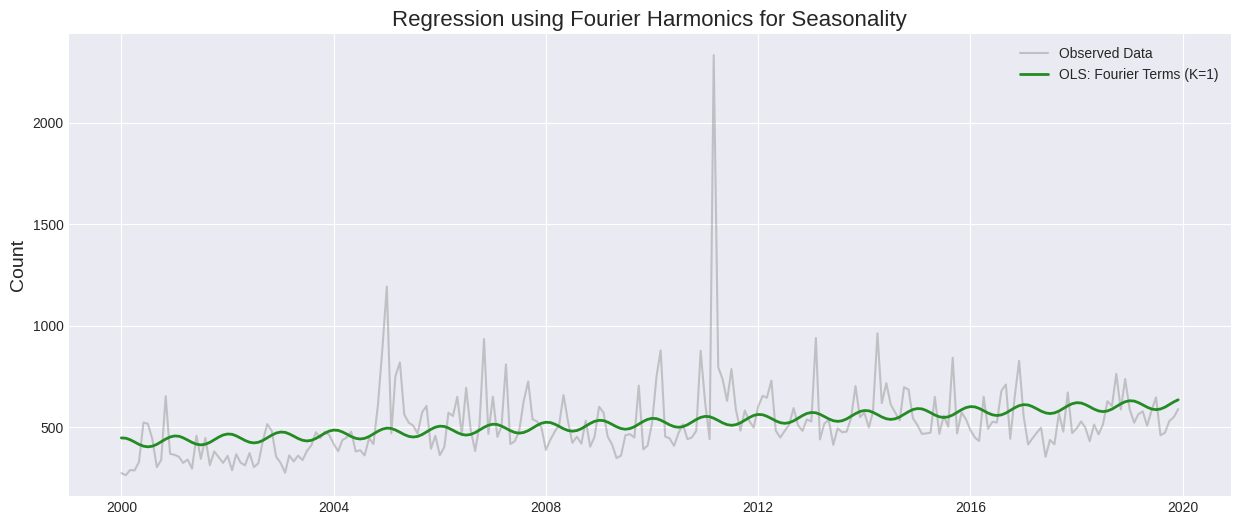

In [86]:
period = 12
df_reg['sin1'] = np.sin(2 * np.pi * df_reg['time_idx'] / period)
df_reg['cos1'] = np.cos(2 * np.pi * df_reg['time_idx'] / period)

X_fourier = sm.add_constant(df_reg[['time_idx', 'sin1', 'cos1']])
fourier_model = sm.OLS(y, X_fourier).fit()
df_reg['fourier_pred'] = fourier_model.predict(X_fourier)

plt.figure(figsize=(15, 6))
plt.plot(df_reg.index, y, label='Observed Data', alpha=0.4, color='gray')
plt.plot(df_reg.index, df_reg['fourier_pred'], label='OLS: Fourier Terms (K=1)', color='forestgreen', lw=2)
plt.title('Regression using Fourier Harmonics for Seasonality')
plt.ylabel('Count')
plt.legend()
plt.show()

### Visualization 14: Intervention Analysis (Spike & Step Effects)
Accounting for an exogenous shock (Tohoku 2011 Earthquake cluster).

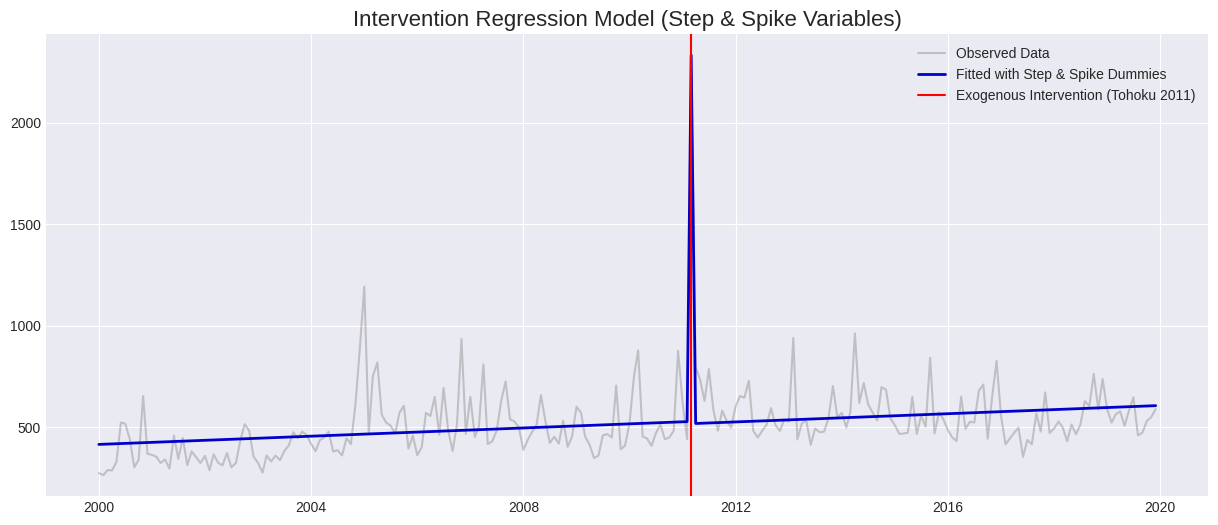

In [87]:
# Creating Intervention Variables
df_reg['intervention_step'] = (df_reg.index >= '2011-03-01').astype(float)
df_reg['intervention_spike'] = (df_reg.index == '2011-03-01').astype(float)

X_int = sm.add_constant(df_reg[['time_idx', 'intervention_step', 'intervention_spike']])
int_model = sm.OLS(y, X_int).fit()
df_reg['int_pred'] = int_model.predict(X_int)

plt.figure(figsize=(15, 6))
plt.plot(df_reg.index, y, label='Observed Data', alpha=0.4, color='gray')
plt.plot(df_reg.index, df_reg['int_pred'], label='Fitted with Step & Spike Dummies', color='mediumblue', lw=2)
plt.axvline(pd.to_datetime('2011-03-01').tz_localize('UTC'), color='red', ls='-', label='Exogenous Intervention (Tohoku 2011)')
plt.title('Intervention Regression Model (Step & Spike Variables)')
plt.legend()
plt.show()

### Visualization 15: Checking for Outliers & Their Influence
We build models with and without an extreme outlier to check the influence parameter. Removing isolates extreme values to avoid distorting coefficients.

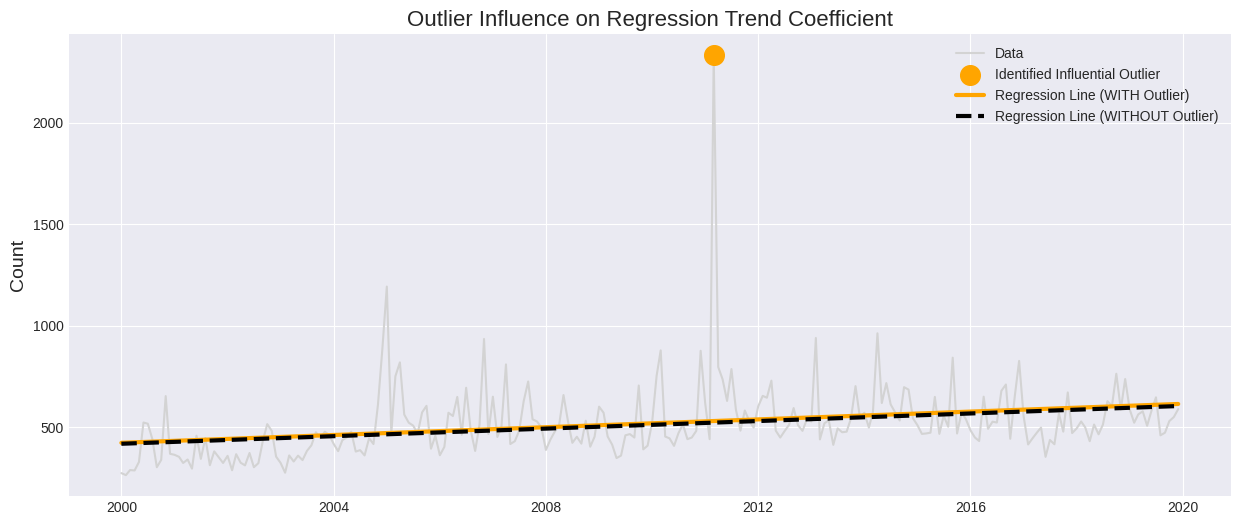

In [88]:
# Identify Max point (Outlier)
max_idx = y.idxmax()

# Model 1: With Outlier
y_with = y.copy()
X_with = sm.add_constant(df_reg[['time_idx']])
model_with = sm.OLS(y_with, X_with).fit()

# Model 2: Without Outlier
y_without = y.drop(max_idx)
X_without = sm.add_constant(df_reg[['time_idx']]).drop(max_idx)
model_without = sm.OLS(y_without, X_without).fit()

plt.figure(figsize=(15, 6))
plt.plot(df_reg.index, y, label='Data', color='lightgrey')
plt.scatter(max_idx, y[max_idx], color='orange', s=200, label='Identified Influential Outlier', zorder=5)

plt.plot(df_reg.index, model_with.predict(X_with), color='orange', lw=3, label='Regression Line (WITH Outlier)')
plt.plot(X_without.index, model_without.predict(X_without), color='black', lw=3, ls='--', label='Regression Line (WITHOUT Outlier)')

plt.title('Outlier Influence on Regression Trend Coefficient')
plt.ylabel('Count')
plt.legend()
plt.show()

## 5. Model Evaluation: Visualization of Residuals
Analysis of the 'Innovation Residuals' from our dummy variable model.
### Visualization 16: Histogram of Residuals
Checking the condition that residuals are normally distributed for computing reliable prediction intervals.

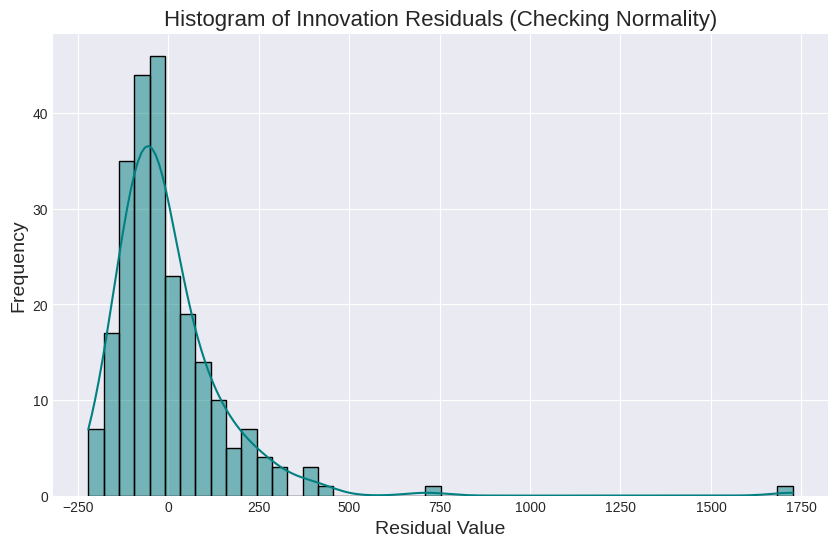

In [89]:
innovation_residuals = lin_model.resid

plt.figure(figsize=(10, 6))
sns.histplot(innovation_residuals, kde=True, color='teal')
plt.title('Histogram of Innovation Residuals (Checking Normality)')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.show()

### Visualization 17: ACF of Residuals
Confirming the assumption of "no autocorrelation in the errors". Violations lead to wider prediction intervals!

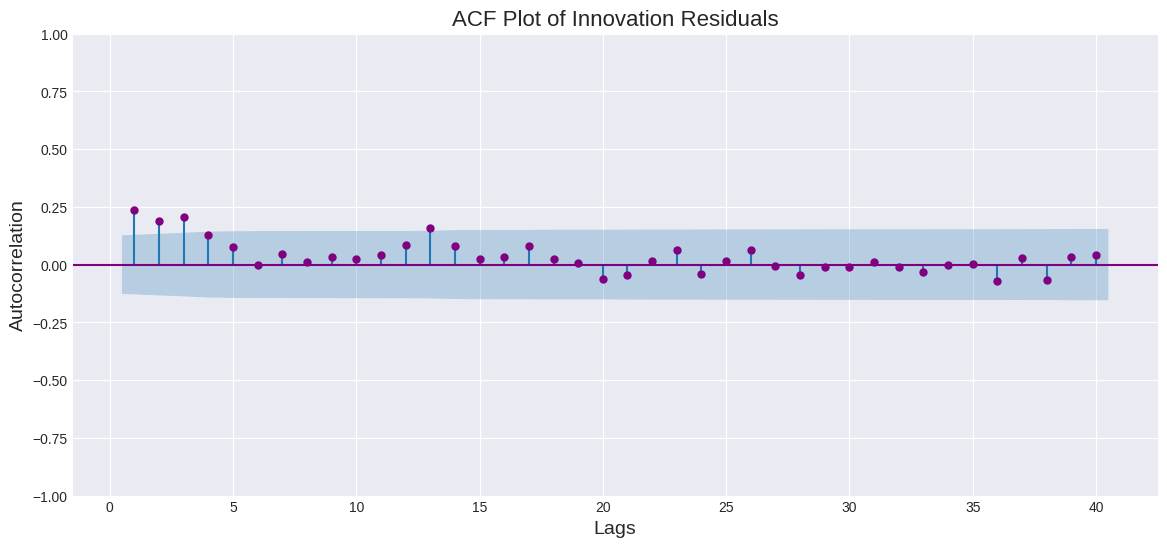

In [90]:
plt.figure(figsize=(14, 6))
ax = plt.gca()
plot_acf(innovation_residuals, ax=ax, lags=40, alpha=0.05, zero=False, color='purple')
plt.title('ACF Plot of Innovation Residuals')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.show()

### Visualization 18: Residuals against Predictors (Fitted Values)
If the scatterplot shows a systemic pattern, the relationship might be non-linear.

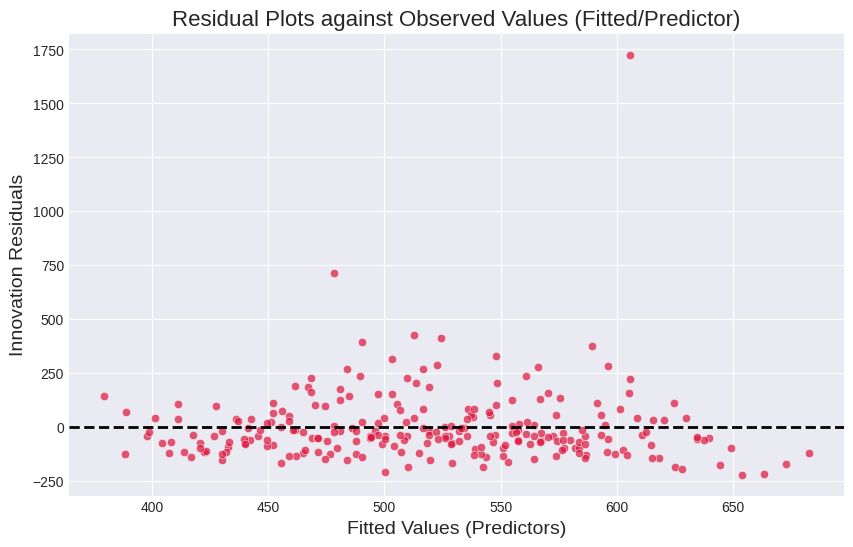

In [91]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=lin_model.fittedvalues, y=innovation_residuals, color='crimson', alpha=0.7)
plt.axhline(0, color='black', ls='--', lw=2)
plt.title('Residual Plots against Observed Values (Fitted/Predictor)')
plt.xlabel('Fitted Values (Predictors)')
plt.ylabel('Innovation Residuals')
plt.show()

## 6. Ex-Post Forecasting with ETS (Exponential Smoothing)
Evaluating Ex-post validation on the Holdout Test Data.
### Visualization 19: SES Overlaid on Holdout Test Set

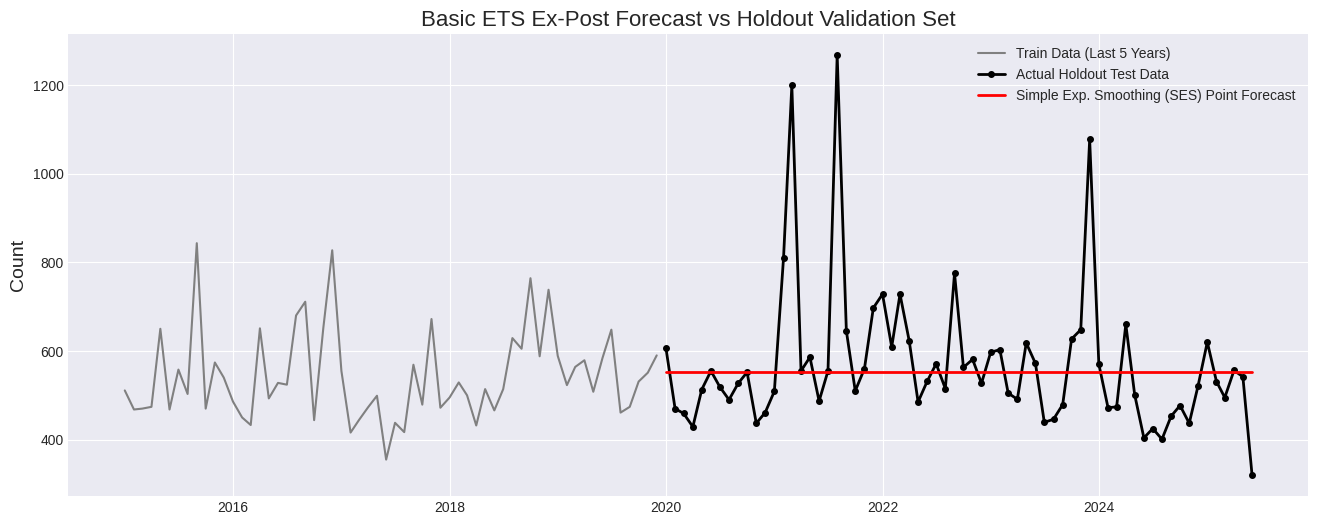

In [92]:
y_train_actual = train['count']

ses_model = SimpleExpSmoothing(y_train_actual).fit(smoothing_level=0.2, optimized=False)
ses_forecast = ses_model.forecast(len(test))

plt.figure(figsize=(16, 6))
plt.plot(y_train_actual.tail(60).index, y_train_actual.tail(60), label='Train Data (Last 5 Years)', color='gray')
plt.plot(test.index, test['count'], label='Actual Holdout Test Data', color='black', lw=2, marker='o', markersize=4)
plt.plot(test.index, ses_forecast, label='Simple Exp. Smoothing (SES) Point Forecast', color='red', lw=2)

plt.title('Basic ETS Ex-Post Forecast vs Holdout Validation Set')
plt.ylabel('Count')
plt.legend()
plt.show()

### Visualization 20: Advanced Holt-Winters Tracking (Additive vs Multiplicative)

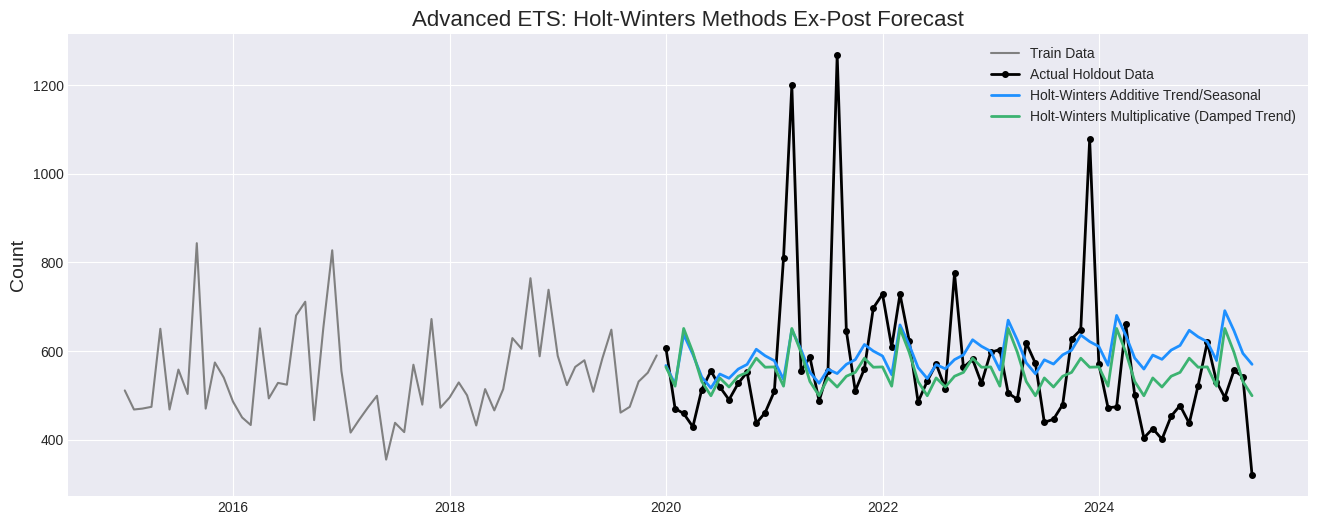

In [93]:
hw_add = ExponentialSmoothing(y_train_actual, seasonal_periods=12, trend='add', seasonal='add').fit()
hw_mult = ExponentialSmoothing(y_train_actual, seasonal_periods=12, trend='add', seasonal='mul', damped_trend=True).fit()

hw_add_pred = hw_add.forecast(len(test))
hw_mult_pred = hw_mult.forecast(len(test))

plt.figure(figsize=(16, 6))
plt.plot(y_train_actual.tail(60).index, y_train_actual.tail(60), label='Train Data', color='gray')
plt.plot(test.index, test['count'], label='Actual Holdout Data', color='black', lw=2, marker='o', markersize=4)

plt.plot(test.index, hw_add_pred, label='Holt-Winters Additive Trend/Seasonal', color='dodgerblue', lw=2)
plt.plot(test.index, hw_mult_pred, label='Holt-Winters Multiplicative (Damped Trend)', color='mediumseagreen', lw=2)

plt.title('Advanced ETS: Holt-Winters Methods Ex-Post Forecast')
plt.ylabel('Count')
plt.legend()
plt.show()

# ### Visualization 20.5: OLS Regression Forecast Validation (Ex-Post)
# Validating the combined Trend + Seasonal Dummy model against the holdout set.

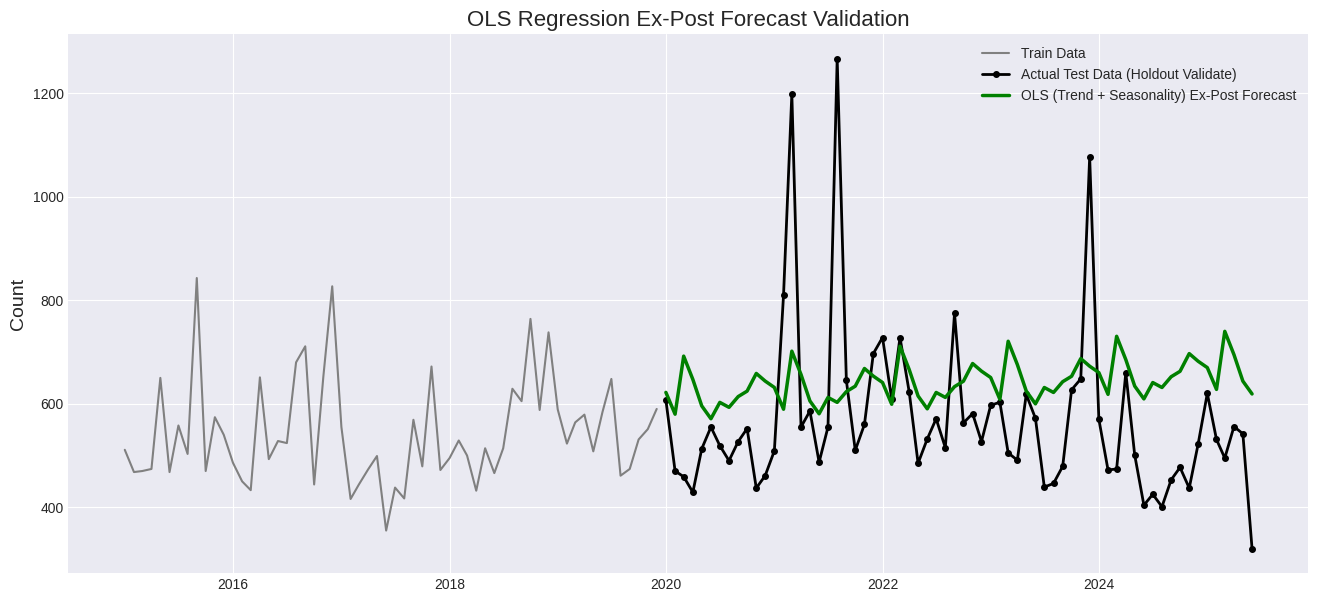

In [94]:
# Re-establish the training data structure for prediction
df_train_eval = train.copy()
df_train_eval['time_idx'] = np.arange(len(df_train_eval))
df_train_eval['month'] = df_train_eval.index.month
df_train_eval = pd.get_dummies(df_train_eval, columns=['month'], drop_first=True)

# Align column structure: Crucial for prediction, must match training columns
# We need to create a feature matrix for the test set that matches the structure of X used in lin_model fitting
test_features = pd.DataFrame(index=test.index)
test_features['time_idx'] = np.arange(len(train), len(ts_data))
test_features['month'] = test_features.index.month
test_features = pd.get_dummies(test_features, columns=['month'], drop_first=True)

# Align columns between test features and training model design matrix (X)
# This ensures that if a dummy variable is missing in the test set (e.g., if the test set doesn't start in Jan), it gets a zero column.
X_train_cols = X.columns.drop('const')
test_features = test_features.reindex(columns=X_train_cols, fill_value=0)
test_features = sm.add_constant(test_features)

# Ensure column order matches the fitted model 'X'
test_features = test_features[X.columns] 

# Predict on Test Set
ols_forecast = lin_model.predict(test_features)

plt.figure(figsize=(16, 7))
plt.plot(y_train_actual.tail(60).index, y_train_actual.tail(60), label='Train Data', color='gray')
plt.plot(test.index, test['count'], label='Actual Test Data (Holdout Validate)', color='black', lw=2, marker='o', markersize=4)

plt.plot(test.index, ols_forecast, label='OLS (Trend + Seasonality) Ex-Post Forecast', color='green', lw=2.5)

plt.title('OLS Regression Ex-Post Forecast Validation')
plt.ylabel('Count')
plt.legend()
plt.show()

## 7. Predictive Regression: ARIMA Forecasting & Predictive Intervals
Generating an ex-post validation forecast on the holdout data utilizing ARIMA with 80% and 95% Confidence Intervals.
### Visualization 21: ARIMA Ex-post Forecast Validation

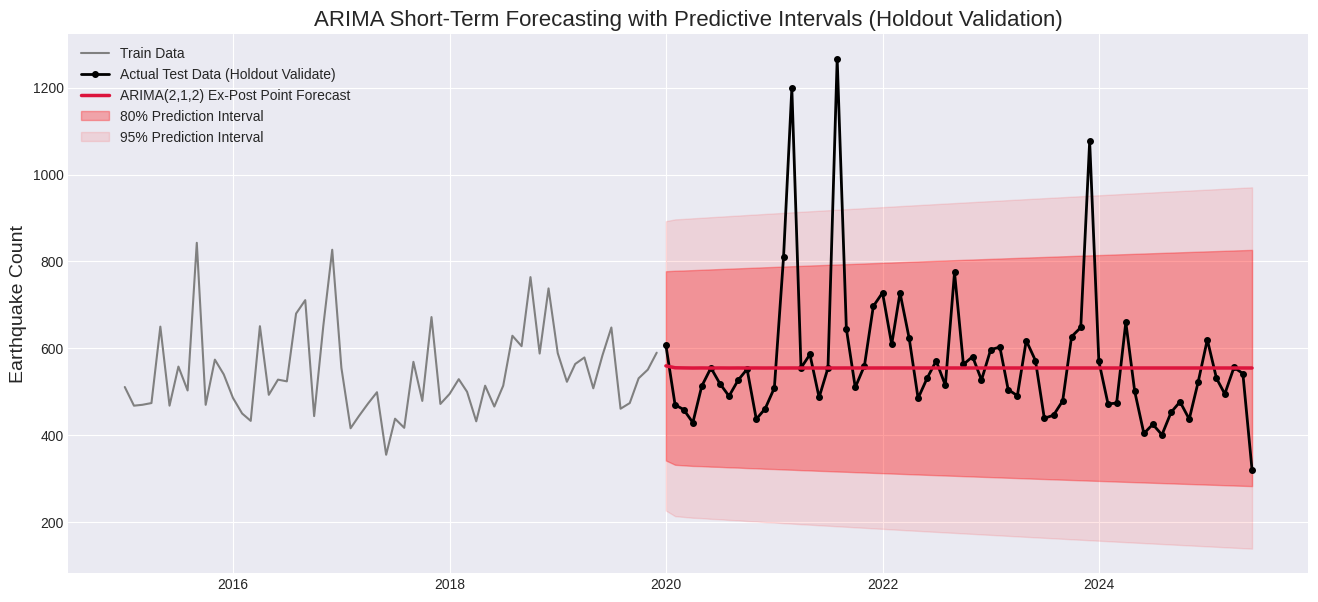

In [95]:
# Fit ARIMA model on training set
arima_model = ARIMA(y_train_actual, order=(2, 1, 2)).fit()
st_forecast = arima_model.get_forecast(steps=len(test))
pred_df_95 = st_forecast.summary_frame(alpha=0.05) # 95% Confidence Interval
pred_df_80 = st_forecast.summary_frame(alpha=0.2)  # 80% Confidence Interval

plt.figure(figsize=(16, 7))
plt.plot(y_train_actual.tail(60).index, y_train_actual.tail(60), label='Train Data', color='gray')
plt.plot(test.index, test['count'], label='Actual Test Data (Holdout Validate)', color='black', lw=2, marker='o', markersize=4)

# Plot point prediction
plt.plot(test.index, pred_df_95['mean'], label='ARIMA(2,1,2) Ex-Post Point Forecast', color='crimson', lw=2.5)

# Shaded confidence bands (Predictive Intervals)
plt.fill_between(test.index, pred_df_80['mean_ci_lower'], pred_df_80['mean_ci_upper'], 
                 color='red', alpha=0.3, label='80% Prediction Interval')
plt.fill_between(test.index, pred_df_95['mean_ci_lower'], pred_df_95['mean_ci_upper'], 
                 color='red', alpha=0.1, label='95% Prediction Interval')

plt.title('ARIMA Short-Term Forecasting with Predictive Intervals (Holdout Validation)')
plt.ylabel('Earthquake Count')
plt.legend()
plt.show()

### Visualization 22: Performance Metrics Comparison (R2, AIC, BIC)
Evaluating the predictive accuracy measures across our models (Adjusted R2, AIC, BIC).

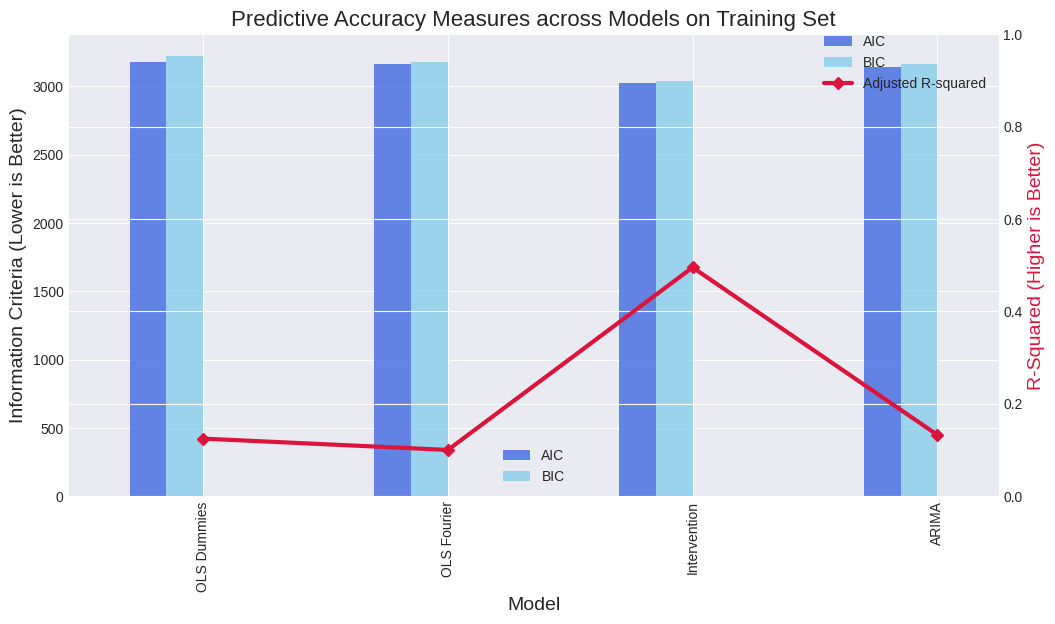

In [96]:
metrics = {
    'Model': ['OLS Dummies', 'OLS Fourier', 'Intervention', 'ARIMA'],
    'AIC': [lin_model.aic, fourier_model.aic, int_model.aic, arima_model.aic],
    'BIC': [lin_model.bic, fourier_model.bic, int_model.bic, arima_model.bic],
    'R2_Train': [lin_model.rsquared, fourier_model.rsquared, int_model.rsquared, r2_score(y_train_actual, arima_model.predict())]
}
metrics_df = pd.DataFrame(metrics).set_index('Model')

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

metrics_df[['AIC', 'BIC']].plot(kind='bar', ax=ax1, position=1, width=0.3, alpha=0.8, color=['royalblue', 'skyblue'])
metrics_df['R2_Train'].plot(kind='line', ax=ax2, color='crimson', marker='D', lw=3, label='Adjusted R-squared')

ax1.set_ylabel('Information Criteria (Lower is Better)')
ax2.set_ylabel('R-Squared (Higher is Better)', color='crimson')
ax2.set_ylim(0, 1)

plt.title('Predictive Accuracy Measures across Models on Training Set')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))
plt.show()

## 8. Final Decision: Ex-Ante Forecast into the Unknown Future
An Ex-Ante forecast is made *before* an event occurs. Here we refit our robust ARIMA model to the complete data and forecast short-term future events out 12 periods.
### Visualization 23: Complete Ex-Ante Future Forecast

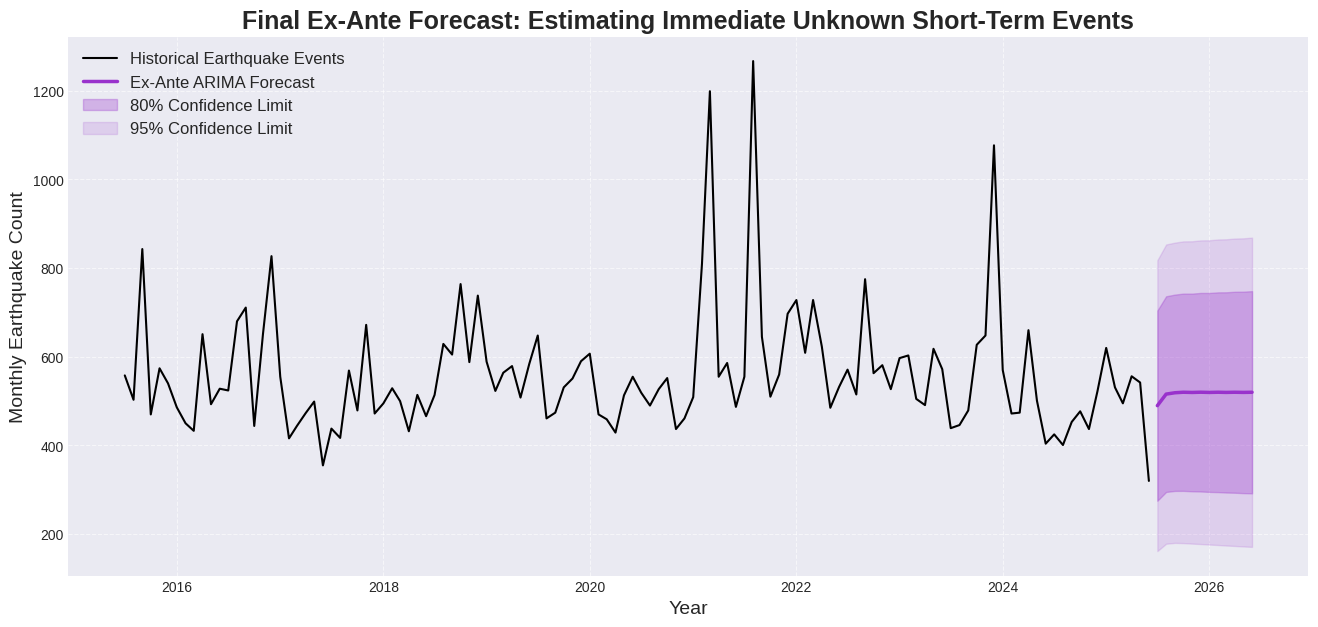

In [97]:
# Refit on Full Data
y_full = ts_data['count']
final_model = ARIMA(y_full, order=(2, 1, 2)).fit()

future_steps = 12
ex_ante = final_model.get_forecast(steps=future_steps)
ex_ante_95 = ex_ante.summary_frame(alpha=0.05)
ex_ante_80 = ex_ante.summary_frame(alpha=0.2)

# Generate future dates
last_date = y_full.index[-1]
future_dates = pd.date_range(last_date + pd.DateOffset(months=1), periods=future_steps, freq='MS')

plt.figure(figsize=(16, 7))
# Historical Data
plt.plot(y_full.tail(120), label='Historical Earthquake Events', color='black', lw=1.5)

# Ex-Ante Point Prediction
plt.plot(future_dates, ex_ante_95['mean'], color='darkorchid', lw=2.5, label='Ex-Ante ARIMA Forecast')

# Prediction Intervals
plt.fill_between(future_dates, ex_ante_80['mean_ci_lower'], ex_ante_80['mean_ci_upper'], 
                 color='darkorchid', alpha=0.3, label='80% Confidence Limit')
plt.fill_between(future_dates, ex_ante_95['mean_ci_lower'], ex_ante_95['mean_ci_upper'], 
                 color='darkorchid', alpha=0.15, label='95% Confidence Limit')

plt.title('Final Ex-Ante Forecast: Estimating Immediate Unknown Short-Term Events', fontsize=18, fontweight='bold')
plt.xlabel('Year', fontsize=14)
plt.ylabel('Monthly Earthquake Count', fontsize=14)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()